# Notebook Evaluasi Algoritma

Notebook ini digunakan untuk mempermudah reporting simulasi, dan berisi:

1. **Authorization key count**
2. **NAKT least-count structural proofing**


## 1. Library Import dan Konfigurasi

In [1]:
import math
import random
import hashlib
import json
import contextlib
import io
from pathlib import Path
from datetime import timedelta

import pandas as pd
import matplotlib.pyplot as plt

import main as sim_config
from broker import Broker
from encryption import decrypt_packet
from laporan import Laporan
from publisher import Publisher, parse_date
from subscriber import Subscriber ,format_date
from matplotlib.collections import LineCollection

In [2]:
# Letak data CSV yang akan digunakan untuk simulasi.
CSV_PATH = sim_config.CSV_PATH
# Nama publisher yang akan digunakan untuk simulasi, pengganti topic karena dalam simulasi ini hanya ada satu publisher.
PUBLISHER_NAME = sim_config.PUBLISHER_NAME
# Kunci master yang digunakan untuk semua simulasi.
MASTER_KEY = sim_config.MASTER_KEY
# Nilai default tingkat granularitas untuk simulasi.
LCNUM = sim_config.LCNUM

# Direktori output untuk menyimpan laporan hasil simulasi.
OUTPUT_DIR = Path("laporan")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Konfigurasi pembuktian granularitas.
# GRANULARITY_VALUES = [1024, 512, 256, 128, 64, 32, 16, 8, 4, 2, 1]
GRANULARITY_VALUES = [1, 5, 30, 180, 360, 1800]
SUBSCRIBER_COUNT = 1
RANDOM_SEED = 42

# Konfigurasi pembuktian algoritma NAKT.
NAKT_RANGE_SIZE_R = None


## 2. Pembuktian jumlah kuci yang dibagikan tiap rentang Granularitas

Bagian ini mengevaluasi berapa banyak unit kunci (key units) yang diperlukan ketika granulasi akses berubah. Pendekatan Standard (flat approach) menghitung kunci daun (leaf keys) satu per satu, sementara pohon hierarkis (hierarchical tree) menghitung node internal bersama (shared internal nodes) yang dikembalikan oleh metode `Publisher.get_key_metrics_for_range()`.

In [3]:
# Helper Code

def total_dataset_days(csv_path):
    """Menghitung jumlah hari dalam dataset CSV."""
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'])
    return (df['Date'].max() - df['Date'].min()).days + 1

def total_leaf_keys_all_granularities(csv_path, granularity_values):
    """Menghitung jumlah kunci daun untuk semua granularitas."""
    total_days = total_dataset_days(csv_path)
    return {g: math.ceil(total_days / g) for g in granularity_values}

def efficiency_percentage(standard_key_count, tree_key_count):
    """Menghitung efisiensi dalam persentase."""
    if standard_key_count == 0:
        return 0
    return ((standard_key_count - tree_key_count) / standard_key_count) * 100


In [14]:
# Membuat reference publisher untuk mendapatkan domain datetime dari dataset yang sama.
broker_ref = Broker()
laporan_ref = Laporan()
publisher_ref = Publisher(
    name=PUBLISHER_NAME,
    broker=broker_ref,
    laporan=laporan_ref,
    csv_path=CSV_PATH,
    master_key=MASTER_KEY,
    lcnum=LCNUM,
)
publisher_ref.setup_datetime_tree()
domain_start, domain_end = publisher_ref.get_datetime_domain()

# Menggenerate rentang akses tetap agar setiap granularitas dievaluasi pada rentang langganan yang sama.
rng = random.Random(RANDOM_SEED)
total_days = (domain_end - domain_start).days
fixed_ranges = []

for _ in range(SUBSCRIBER_COUNT):
    a = rng.randint(0, total_days)
    b = rng.randint(0, total_days)
    range_start = domain_start + timedelta(days=min(a, b))
    range_end = domain_start + timedelta(days=max(a, b))
    fixed_ranges.append((range_start, range_end))

key_metrics_summary = []

for granularity_days in GRANULARITY_VALUES:
    broker = Broker()
    laporan = Laporan()
    publisher = Publisher(
        name=PUBLISHER_NAME,
        broker=broker,
        laporan=laporan,
        csv_path=CSV_PATH,
        master_key=MASTER_KEY,
        lcnum=granularity_days,
    )
    publisher.setup_datetime_tree()

    standard_key_counts = []
    tree_node_counts = []
    access_duration_days = []

    for range_start, range_end in fixed_ranges:
        metrics = publisher.get_key_metrics_for_range(range_start, range_end)
        standard_key_counts.append(total_dataset_days(CSV_PATH) )#// granularity_days)
        tree_node_counts.append(total_leaf_keys_all_granularities(CSV_PATH, [granularity_days])[granularity_days])
        access_duration_days.append(metrics["access_duration_days"])

    key_metrics_summary.append({
        "granularity_days_G": granularity_days,
        "standard_key_count": sum(standard_key_counts),
        "tree_key_count": sum(tree_node_counts),
        "efficiency_percentage": f"{efficiency_percentage(sum(standard_key_counts), sum(tree_node_counts)):.2f}%",
    })

shared_key_df = pd.DataFrame(key_metrics_summary)
shared_key_csv = OUTPUT_DIR / "granularity_validation_results.csv"
shared_key_df.to_csv(shared_key_csv, index=False)

print(f"Metrik kunci disimpan ke: {shared_key_csv}")
shared_key_df

Metrik kunci disimpan ke: laporan\granularity_validation_results.csv


,granularity_days_G,standard_key_count,tree_key_count,efficiency_percentage
0,1,3649,3649,0.00%
1,5,3649,730,79.99%
2,30,3649,122,96.66%
3,180,3649,21,99.42%
4,360,3649,11,99.70%
5,1800,3649,3,99.92%


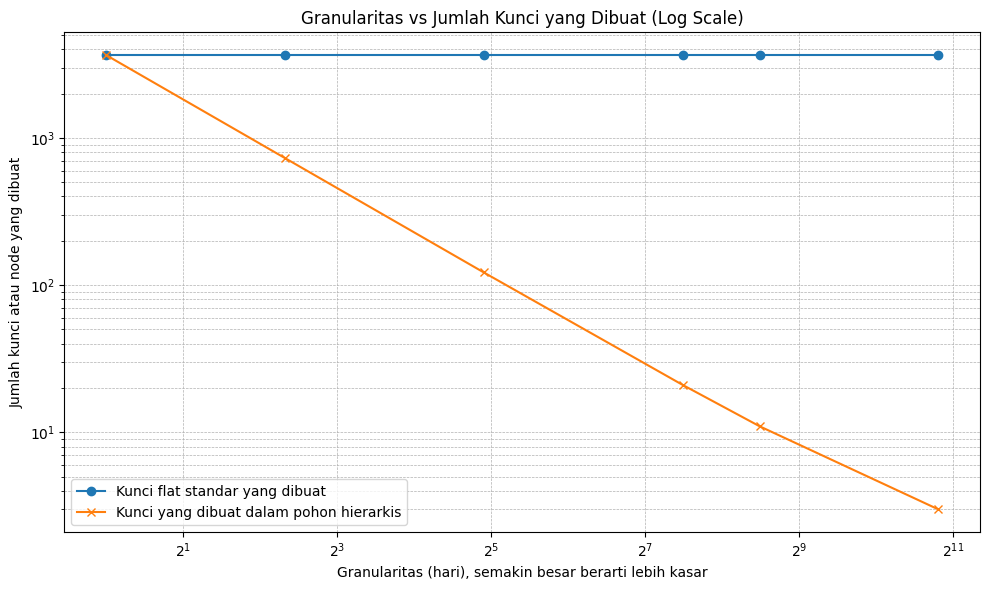

Grafik Granularitas vs Jumlah Kunci disimpan ke : laporan\granularity_vs_key_count.png


In [5]:
key_plot = OUTPUT_DIR / "granularity_vs_key_count.png"

plt.figure(figsize=(10, 6))
plt.plot(
    shared_key_df["granularity_days_G"],
    shared_key_df["standard_key_count"],
    marker="o",
    label="Kunci flat standar yang dibuat",
)
plt.plot(
    shared_key_df["granularity_days_G"],
    shared_key_df["tree_key_count"],
    marker="x",
    label="Kunci yang dibuat dalam pohon hierarkis",
)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Granularitas (hari), semakin besar berarti lebih kasar")
plt.ylabel("Jumlah kunci atau node yang dibuat")
plt.title("Granularitas vs Jumlah Kunci yang Dibuat (Log Scale)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(key_plot, dpi=200)
plt.show()

print(f"Grafik Granularitas vs Jumlah Kunci disimpan ke : {key_plot}")

## 3. Tabel pembuktian enkripsi dan dekripsi untuk setiap granularitas

Cell ini membuktikan bahwa satu subscriber dengan range akses acak yang sama dapat menerima dan mendekripsi packet pada setiap nilai `GRANULARITY_VALUES`. Untuk menjaga tabel tetap ringkas, setiap granularitas hanya menampilkan satu leaf representatif yang memiliki data aktual. Seluruh data aktual dalam leaf tersebut tetap diuji.


In [6]:
# Range subscriber dibuat random satu kali dari tanggal aktual dataset, lalu digunakan sama untuk semua granularitas.
# Random tetap reproducible karena memakai RANDOM_SEED.
# Range dibatasi agar tidak terlalu besar dan tidak dipilih berdasarkan target jumlah key tertentu.

proof_dataset = publisher_ref.df.copy()
proof_dataset["_parsed_date"] = proof_dataset["Date"].map(lambda value: parse_date(str(value)))
proof_dataset = proof_dataset.sort_values("_parsed_date").reset_index(drop=True)
proof_available_dates = sorted(proof_dataset["_parsed_date"].dropna().unique())

# Batas ini dapat diubah jika ingin range pembuktian lebih pendek atau lebih panjang.
PROOF_RANDOM_RANGE_MIN_DAYS = 45
PROOF_RANDOM_RANGE_MAX_DAYS = 120
PROOF_MIN_DATA_IN_RANGE = 10

# Start dan end dipilih random dari tanggal aktual dataset.
proof_rng = random.Random(RANDOM_SEED)
proof_range_start = None
proof_range_end = None

for proof_attempt in range(len(proof_dataset)):
    proof_start_idx, proof_end_idx = sorted(proof_rng.sample(range(len(proof_available_dates)), 2))
    proof_candidate_start = proof_available_dates[proof_start_idx]
    proof_candidate_end = proof_available_dates[proof_end_idx]
    proof_candidate_days = (proof_candidate_end - proof_candidate_start).days + 1

    if not (PROOF_RANDOM_RANGE_MIN_DAYS <= proof_candidate_days <= PROOF_RANDOM_RANGE_MAX_DAYS):
        continue

    proof_candidate_rows = proof_dataset[
        (proof_dataset["_parsed_date"] >= proof_candidate_start)
        & (proof_dataset["_parsed_date"] <= proof_candidate_end)
    ]

    if len(proof_candidate_rows) >= PROOF_MIN_DATA_IN_RANGE:
        proof_range_start = proof_candidate_start
        proof_range_end = proof_candidate_end
        break

if proof_range_start is None or proof_range_end is None:
    raise ValueError(
        "Tidak ditemukan range random yang memenuhi batas durasi dan jumlah data aktual. "
        "Longgarkan PROOF_RANDOM_RANGE_MIN_DAYS, PROOF_RANDOM_RANGE_MAX_DAYS, atau PROOF_MIN_DATA_IN_RANGE."
    )

proof_candidates = proof_dataset[
    (proof_dataset["_parsed_date"] >= proof_range_start)
    & (proof_dataset["_parsed_date"] <= proof_range_end)
].sort_values("_parsed_date").reset_index(drop=True)

if proof_candidates.empty:
    raise ValueError("Tidak ada data aktual dalam range subscriber yang terpilih.")

proof_rows = []
proof_range_days = (proof_range_end - proof_range_start).days + 1

for proof_granularity in GRANULARITY_VALUES:
    proof_broker = Broker()
    proof_laporan = Laporan()
    proof_publisher = Publisher(
        name=PUBLISHER_NAME,
        broker=proof_broker,
        laporan=proof_laporan,
        csv_path=CSV_PATH,
        master_key=MASTER_KEY,
        lcnum=proof_granularity,
    )
    proof_publisher.setup_datetime_tree()

    proof_subscriber = Subscriber(name=f"ProofSubscriber-G{proof_granularity}")
    proof_subscriber.range_start = format_date(proof_range_start)
    proof_subscriber.range_end = format_date(proof_range_end)

    with contextlib.redirect_stdout(io.StringIO()):
        proof_broker.subscribe(PUBLISHER_NAME, proof_subscriber)
    proof_access_keys = proof_publisher.issue_keys_for_subscriber(proof_subscriber)

    proof_leaf_nodes_in_range = proof_publisher._retrieve_leaf_nodes_in_range(
        node=proof_publisher.root,
        query_start=proof_range_start,
        query_end=proof_range_end,
    )

    proof_leaf_rows = []
    for proof_leaf_node in proof_leaf_nodes_in_range:
        proof_leaf_data = proof_dataset[
            (proof_dataset["_parsed_date"] >= max(proof_leaf_node.start_date, proof_range_start))
            & (proof_dataset["_parsed_date"] <= min(proof_leaf_node.end_date, proof_range_end))
        ].sort_values("_parsed_date").reset_index(drop=True)

        if not proof_leaf_data.empty:
            proof_leaf_rows.append((proof_leaf_node, proof_leaf_data))

    if not proof_leaf_rows:
        raise ValueError("Tidak ada data aktual pada leaf yang beririsan dengan range subscriber.")

    # Tabel tesis dibuat ringkas: hanya satu leaf representatif untuk setiap granularitas.
    # Leaf dipilih dari posisi tengah agar tidak selalu mengambil batas awal atau akhir range subscriber.
    proof_leaf_node, proof_leaf_data = proof_leaf_rows[len(proof_leaf_rows) // 2]

    proof_used_auth_nodes = []
    proof_original_values = []
    proof_decrypted_values = []
    proof_valid_count = 0

    for proof_sequence, (_, proof_sample_row) in enumerate(proof_leaf_data.iterrows(), start=1):
        proof_event_date = parse_date(str(proof_sample_row["Date"]))
        proof_close_value = float(
            str(proof_sample_row["Close"])
            .replace("$", "")
            .replace(",", "")
            .strip()
        )
        proof_record = {
            "timestamp": format_date(proof_event_date),
            "close": proof_close_value,
        }

        proof_actual_leaf_node = proof_publisher._retrieve_leaf(
            proof_publisher.root,
            proof_event_date,
        )
        proof_encrypted_packet = proof_publisher._encrypt_payload(
            sequence=proof_sequence,
            record=proof_record,
            leaf_node=proof_actual_leaf_node,
        )

        # Broker hanya meneruskan packet terenkripsi ke subscriber.
        with contextlib.redirect_stdout(io.StringIO()):
            proof_broker.publish(PUBLISHER_NAME, proof_encrypted_packet)

        # Subscriber mencari authorization node yang relevan, lalu menurunkan key sampai leaf event.
        proof_auth_key = proof_subscriber._find_key(proof_encrypted_packet)
        if proof_auth_key is None:
            raise ValueError("Subscriber tidak menemukan authorization key untuk packet uji.")

        proof_leaf_key = proof_subscriber._derive_child_key(
            auth_key=proof_auth_key,
            encrypted_packet=proof_encrypted_packet,
        )
        proof_decrypted_payload = decrypt_packet(
            encrypted_packet=proof_encrypted_packet,
            key=proof_leaf_key,
        )

        proof_original_hash = hashlib.sha256(
            json.dumps(proof_record, sort_keys=True).encode("utf-8")
        ).hexdigest()
        proof_decrypted_hash = hashlib.sha256(
            json.dumps(proof_decrypted_payload, sort_keys=True).encode("utf-8")
        ).hexdigest()

        if proof_original_hash == proof_encrypted_packet["payload_hash"] == proof_decrypted_hash:
            proof_valid_count += 1

        proof_used_auth_nodes.append(
            f"{proof_auth_key['node_label'] or 'ROOT'} "
            f"({proof_auth_key['range_start']} sampai {proof_auth_key['range_end']})"
        )
        proof_original_values.append(
            f"{proof_record['timestamp']}: close={proof_record['close']}"
        )
        proof_decrypted_values.append(
            f"{proof_decrypted_payload['timestamp']}: close={proof_decrypted_payload['close']}"
        )

    proof_rows.append({
        "Granularitas": f"{proof_granularity} hari",
        "Range yang Diminta Subscriber": (
            f"{proof_subscriber.range_start} sampai {proof_subscriber.range_end} "
            f"({proof_range_days} hari kalender, {len(proof_candidates)} data aktual)"
        ),
        "Jumlah Key Diterima": len(proof_access_keys),
        "Jumlah Leaf dalam Range Subscriber": len(proof_leaf_nodes_in_range),
        "Label Node Otorisasi yang Dipakai": " | ".join(dict.fromkeys(proof_used_auth_nodes)),
        "Label Leaf Event yang Diuji": proof_leaf_node.label or "ROOT",
        "Range Leaf Event": (
            f"{format_date(proof_leaf_node.start_date)} sampai {format_date(proof_leaf_node.end_date)}"
        ),
        "Jumlah Data Aktual dalam Leaf yang Diuji": len(proof_leaf_data),
        "Data Asli dari Dataset dalam Leaf": " | ".join(proof_original_values),
        "Hasil Decrypt Data dalam Leaf": " | ".join(proof_decrypted_values),
        "Status Validasi": f"Berhasil {proof_valid_count}/{len(proof_leaf_data)} data",
    })

proof_decryption_table = pd.DataFrame(proof_rows)
proof_decryption_csv_path = OUTPUT_DIR / "proof_decryption_one_leaf_per_granularity.csv"
proof_decryption_table.to_csv(proof_decryption_csv_path, index=False, encoding="utf-8-sig")
pd.set_option("display.max_colwidth", None)

print(
    "Range subscriber random yang digunakan:",
    f"{format_date(proof_range_start)} sampai {format_date(proof_range_end)}",
    f"({proof_range_days} hari kalender, {len(proof_candidates)} data aktual, seed={RANDOM_SEED})",
)
print(f"CSV tabel pembuktian disimpan ke: {proof_decryption_csv_path}")
proof_decryption_table



Range subscriber random yang digunakan: 2020-01-13 sampai 2020-04-03 (82 hari kalender, 58 data aktual, seed=42)
CSV tabel pembuktian disimpan ke: laporan\proof_decryption_one_leaf_per_granularity.csv


,Granularitas,Range yang Diminta Subscriber,Jumlah Key Diterima,Jumlah Leaf dalam Range Subscriber,Label Node Otorisasi yang Dipakai,Label Leaf Event yang Diuji,Range Leaf Event,Jumlah Data Aktual dalam Leaf yang Diuji,Data Asli dari Dataset dalam Leaf,Hasil Decrypt Data dalam Leaf,Status Validasi
0,1 hari,"2020-01-13 sampai 2020-04-03 (82 hari kalender, 58 data aktual)",7,82,010111 (2020-01-25 sampai 2020-03-21),010111100010,2020-02-25 sampai 2020-02-25,1,2020-02-25: close=69.42,2020-02-25: close=69.42,Berhasil 1/1 data
1,5 hari,"2020-01-13 sampai 2020-04-03 (82 hari kalender, 58 data aktual)",7,24,010111 (2020-01-25 sampai 2020-03-21),0101111000,2020-02-23 sampai 2020-02-26,3,2020-02-24: close=71.08 | 2020-02-25: close=69.42 | 2020-02-26: close=69.66,2020-02-24: close=71.08 | 2020-02-25: close=69.42 | 2020-02-26: close=69.66,Berhasil 3/3 data
2,30 hari,"2020-01-13 sampai 2020-04-03 (82 hari kalender, 58 data aktual)",3,4,010111 (2020-01-25 sampai 2020-03-21),0101111,2020-02-23 sampai 2020-03-21,20,2020-02-24: close=71.08 | 2020-02-25: close=69.42 | 2020-02-26: close=69.66 | 2020-02-27: close=65.9 | 2020-02-28: close=66.97 | 2020-03-02: close=69.46 | 2020-03-03: close=67.07 | 2020-03-04: close=69.33 | 2020-03-05: close=65.95 | 2020-03-06: close=64.92 | 2020-03-09: close=60.78 | 2020-03-10: close=64.02 | 2020-03-11: close=60.77 | 2020-03-12: close=55.75 | 2020-03-13: close=60.99 | 2020-03-16: close=54.22 | 2020-03-17: close=55.99 | 2020-03-18: close=54.84 | 2020-03-19: close=55.76 | 2020-03-20: close=53.62,2020-02-24: close=71.08 | 2020-02-25: close=69.42 | 2020-02-26: close=69.66 | 2020-02-27: close=65.9 | 2020-02-28: close=66.97 | 2020-03-02: close=69.46 | 2020-03-03: close=67.07 | 2020-03-04: close=69.33 | 2020-03-05: close=65.95 | 2020-03-06: close=64.92 | 2020-03-09: close=60.78 | 2020-03-10: close=64.02 | 2020-03-11: close=60.77 | 2020-03-12: close=55.75 | 2020-03-13: close=60.99 | 2020-03-16: close=54.22 | 2020-03-17: close=55.99 | 2020-03-18: close=54.84 | 2020-03-19: close=55.76 | 2020-03-20: close=53.62,Berhasil 20/20 data
3,180 hari,"2020-01-13 sampai 2020-04-03 (82 hari kalender, 58 data aktual)",2,2,01100 (2020-03-22 sampai 2020-07-13),01100,2020-03-22 sampai 2020-07-13,10,2020-03-23: close=52.83 | 2020-03-24: close=56.72 | 2020-03-25: close=55.12 | 2020-03-26: close=58.09 | 2020-03-27: close=55.54 | 2020-03-30: close=57.34 | 2020-03-31: close=58.14 | 2020-04-01: close=55.28 | 2020-04-02: close=56.04 | 2020-04-03: close=54.89,2020-03-23: close=52.83 | 2020-03-24: close=56.72 | 2020-03-25: close=55.12 | 2020-03-26: close=58.09 | 2020-03-27: close=55.54 | 2020-03-30: close=57.34 | 2020-03-31: close=58.14 | 2020-04-01: close=55.28 | 2020-04-02: close=56.04 | 2020-04-03: close=54.89,Berhasil 10/10 data
4,360 hari,"2020-01-13 sampai 2020-04-03 (82 hari kalender, 58 data aktual)",2,2,0110 (2020-03-22 sampai 2020-11-04),0110,2020-03-22 sampai 2020-11-04,10,2020-03-23: close=52.83 | 2020-03-24: close=56.72 | 2020-03-25: close=55.12 | 2020-03-26: close=58.09 | 2020-03-27: close=55.54 | 2020-03-30: close=57.34 | 2020-03-31: close=58.14 | 2020-04-01: close=55.28 | 2020-04-02: close=56.04 | 2020-04-03: close=54.89,2020-03-23: close=52.83 | 2020-03-24: close=56.72 | 2020-03-25: close=55.12 | 2020-03-26: close=58.09 | 2020-03-27: close=55.54 | 2020-03-30: close=57.34 | 2020-03-31: close=58.14 | 2020-04-01: close=55.28 | 2020-04-02: close=56.04 | 2020-04-03: close=54.89,Berhasil 10/10 data
5,1800 hari,"2020-01-13 sampai 2020-04-03 (82 hari kalender, 58 data aktual)",1,1,01 (2018-12-22 sampai 2021-06-20),01,2018-12-22 sampai 2021-06-20,58,2020-01-13: close=71.96 | 2020-01-14: close=71.54 | 2020-01-15: close=71.96 | 2020-01-16: close=72.59 | 2020-01-17: close=74.02 | 2020-01-21: close=74.22 | 2020-01-22: close=74.3 | 2020-01-23: close=74.33 | 2020-01-24: close=73.34 | 2020-01-27: close=71.7 | 2020-01-28: close=72.63 | 2020-01-29: close=72.93 | 2020-01-30: close=72.79 | 2020-01-31: close=71.71 | 2020-02-03: close=74.3 | 2020-02-04:

## 4. Visualisasi Tree
Visualisasi graph tree untuk setiap nilai GRANULARITY_VALUES. Setiap panel memperlihatkan struktur Hierarchical Key Tree/NAKT yang terbentuk pada satu nilai granularitas. Semakin kecil granularitas, semakin dalam pohon dan semakin banyak leaf yang terbentuk.

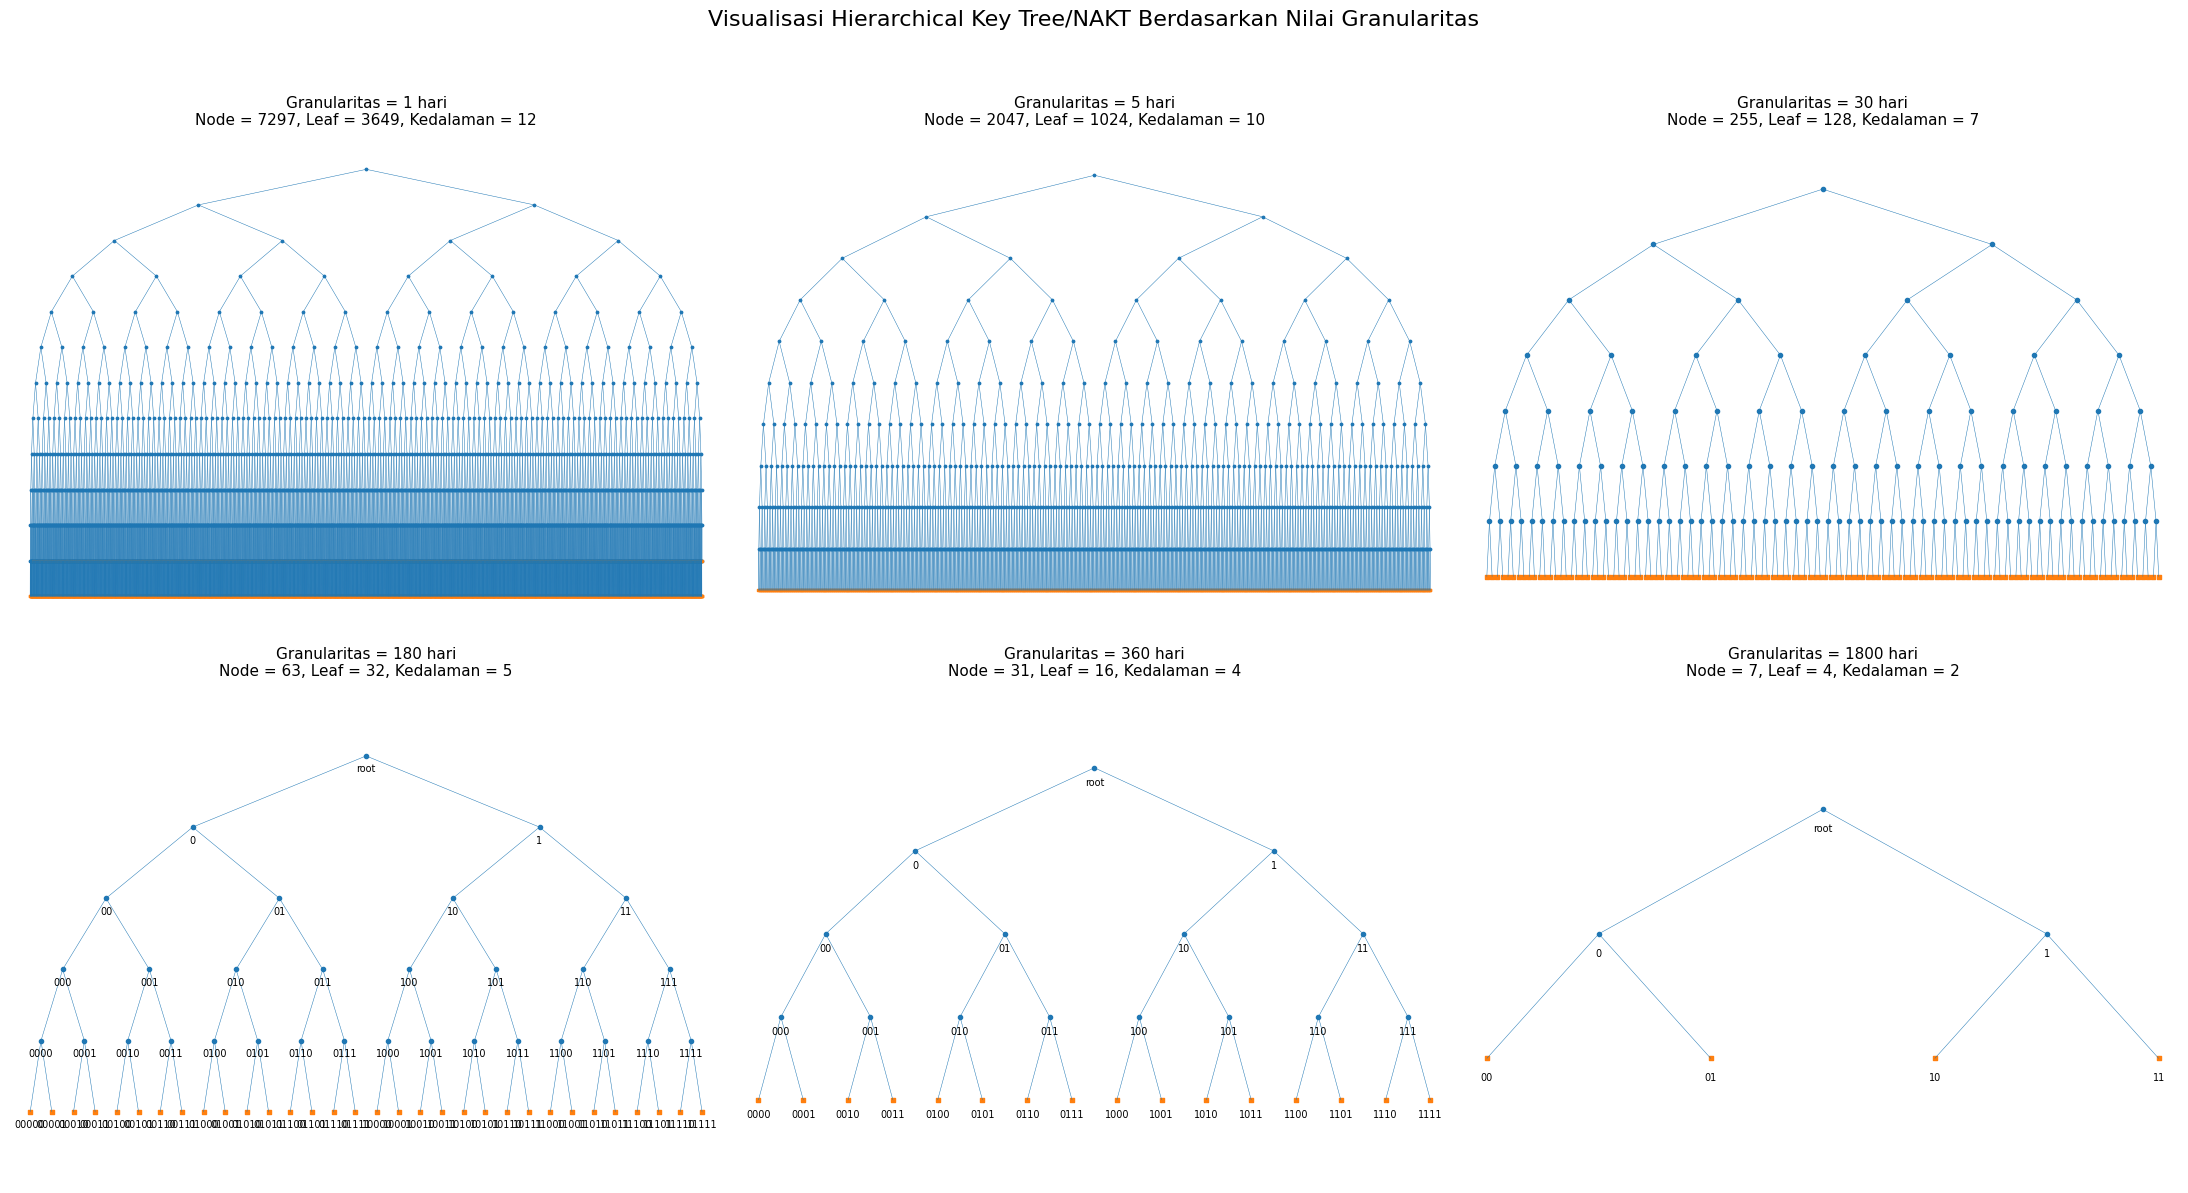

Graph tree seluruh granularitas disimpan ke: laporan\nakt_tree_graph_by_granularity.png


In [7]:
def _collect_tree_metrics(node, depth=0):
    if node is None:
        return {"total_nodes": 0, "leaf_nodes": 0, "max_depth": depth}

    if node.is_leaf():
        return {"total_nodes": 1, "leaf_nodes": 1, "max_depth": depth}

    left_metrics = _collect_tree_metrics(node.left, depth + 1)
    right_metrics = _collect_tree_metrics(node.right, depth + 1)

    return {
        "total_nodes": 1 + left_metrics["total_nodes"] + right_metrics["total_nodes"],
        "leaf_nodes": left_metrics["leaf_nodes"] + right_metrics["leaf_nodes"],
        "max_depth": max(left_metrics["max_depth"], right_metrics["max_depth"]),
    }


def _make_tree_layout(root_node):
    nodes = []
    edges = []
    leaf_counter = [0]

    def _visit(node, depth):
        node_index = len(nodes)
        nodes.append(
            {
                "label": node.label if node.label else "root",
                "range": f"{format_date(node.start_date)} - {format_date(node.end_date)}",
                "depth": depth,
                "is_leaf": node.is_leaf(),
                "x": None,
                "y": -depth,
            }
        )

        if node.is_leaf():
            nodes[node_index]["x"] = leaf_counter[0]
            leaf_counter[0] += 1
            return node_index

        left_index = _visit(node.left, depth + 1)
        right_index = _visit(node.right, depth + 1)
        nodes[node_index]["x"] = (nodes[left_index]["x"] + nodes[right_index]["x"]) / 2
        edges.append((node_index, left_index))
        edges.append((node_index, right_index))

        return node_index

    _visit(root_node, 0)

    max_x = max(node["x"] for node in nodes) if nodes else 1
    if max_x == 0:
        max_x = 1

    for node in nodes:
        node["x"] = node["x"] / max_x

    return nodes, edges


fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for ax, granularity_days in zip(axes, GRANULARITY_VALUES):
    tree_broker = Broker()
    tree_laporan = Laporan()
    tree_publisher = Publisher(
        name=PUBLISHER_NAME,
        broker=tree_broker,
        laporan=tree_laporan,
        csv_path=CSV_PATH,
        master_key=MASTER_KEY,
        lcnum=granularity_days,
    )
    tree_publisher.setup_datetime_tree()

    metrics = _collect_tree_metrics(tree_publisher.root)
    nodes, edges = _make_tree_layout(tree_publisher.root)

    line_segments = [
        [
            (nodes[parent_index]["x"], nodes[parent_index]["y"]),
            (nodes[child_index]["x"], nodes[child_index]["y"]),
        ]
        for parent_index, child_index in edges
    ]

    if line_segments:
        ax.add_collection(LineCollection(line_segments, linewidths=0.35))

    internal_nodes = [node for node in nodes if not node["is_leaf"]]
    leaf_nodes = [node for node in nodes if node["is_leaf"]]

    node_size = 9 if metrics["total_nodes"] <= 300 else 3
    leaf_size = 10 if metrics["total_nodes"] <= 300 else 3

    if internal_nodes:
        ax.scatter(
            [node["x"] for node in internal_nodes],
            [node["y"] for node in internal_nodes],
            s=node_size,
            marker="o",
            label="Node internal",
        )

    if leaf_nodes:
        ax.scatter(
            [node["x"] for node in leaf_nodes],
            [node["y"] for node in leaf_nodes],
            s=leaf_size,
            marker="s",
            label="Leaf node",
        )

    # Label hanya ditampilkan pada pohon kecil agar gambar tetap terbaca.
    if metrics["total_nodes"] <= 70:
        for node in nodes:
            ax.text(
                node["x"],
                node["y"] - 0.12,
                node["label"],
                ha="center",
                va="top",
                fontsize=7,
            )

    ax.set_title(
        f"Granularitas = {granularity_days} hari\n"
        f"Node = {metrics['total_nodes']}, Leaf = {metrics['leaf_nodes']}, Kedalaman = {metrics['max_depth']}",
        fontsize=11,
    )
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-metrics["max_depth"] - 1, 1)
    ax.axis("off")


for ax in axes[len(GRANULARITY_VALUES):]:
    ax.axis("off")

fig.suptitle(
    "Visualisasi Hierarchical Key Tree/NAKT Berdasarkan Nilai Granularitas",
    fontsize=16,
    y=0.99,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

tree_graph_path = OUTPUT_DIR / "nakt_tree_graph_by_granularity.png"
fig.savefig(tree_graph_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Graph tree seluruh granularitas disimpan ke: {tree_graph_path}")


## 5. Pembuktian algoritma NAKT

Bagian ini membuat grafik pembuktian untuk algoritma NAKT. Ukuran rentang `R` diambil dari domain tanggal-waktu (datetime domain) sebenarnya dari data CSV yang digunakan.

In [8]:
# Metrik NAKT least-count dihitung berdasarkan domain datetime dari dataset yang sama.
if "domain_start" not in globals() or "domain_end" not in globals():
    broker_ref = Broker()
    laporan_ref = Laporan()
    publisher_ref = Publisher(
        name=PUBLISHER_NAME,
        broker=broker_ref,
        laporan=laporan_ref,
        csv_path=CSV_PATH,
        master_key=MASTER_KEY,
        lcnum=LCNUM,
    )
    publisher_ref.setup_datetime_tree()
    domain_start, domain_end = publisher_ref.get_datetime_domain()

NAKT_RANGE_SIZE_R = (domain_end - domain_start).days + 1

least_count_results = []

for least_count in GRANULARITY_VALUES:
    if least_count < 1:
        continue
    if least_count > NAKT_RANGE_SIZE_R:
        continue

    normalized_leaf_blocks = NAKT_RANGE_SIZE_R / least_count

    if normalized_leaf_blocks <= 1:
        tree_height = 0
        avg_keys_per_subscription = 1
    else:
        tree_height = math.ceil(math.log2(normalized_leaf_blocks))
        avg_keys_per_subscription = 0.5 * math.log2(normalized_leaf_blocks)

    least_count_results.append({
        "range_size_R": NAKT_RANGE_SIZE_R,
        "least_count_lc": least_count,
        "tree_height": tree_height,
        "avg_keys_per_subscription_est": round(avg_keys_per_subscription, 3),
    })

least_count_df = pd.DataFrame(least_count_results)
least_count_csv = OUTPUT_DIR / "nakt_least_count_metrics.csv"
least_count_df.to_csv(least_count_csv, index=False)

print(f"Jumlah rentang data R : {NAKT_RANGE_SIZE_R} days ({format_date(domain_start)} to {format_date(domain_end)})")
print(f"Metrik NAKT least-count disimpan ke: {least_count_csv}")
least_count_df


Jumlah rentang data R : 3649 days (2016-06-22 to 2026-06-18)
Metrik NAKT least-count disimpan ke: laporan\nakt_least_count_metrics.csv


,range_size_R,least_count_lc,tree_height,avg_keys_per_subscription_est
0,3649,1,12,5.917
1,3649,5,10,4.756
2,3649,30,7,3.463
3,3649,180,5,2.171
4,3649,360,4,1.671
5,3649,1800,2,0.510


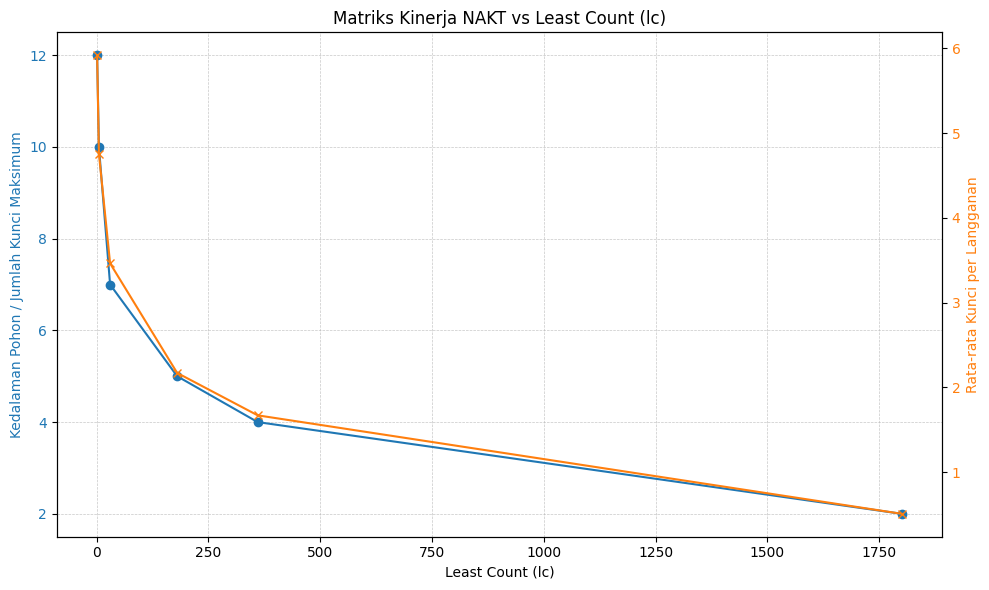

Grafik NAKT vs Least Count disimpan ke : laporan\nakt_performance_vs_least_count.png


In [9]:
least_count_plot = OUTPUT_DIR / "nakt_performance_vs_least_count.png"

fig, ax1 = plt.subplots(figsize=(10, 6))
left_color = "tab:blue"
right_color = "tab:orange"

ax1.plot(
    least_count_df["least_count_lc"],
    least_count_df["tree_height"],
    marker="o",
    color=left_color,
)
ax1.set_xlabel("Least Count (lc)")
ax1.set_ylabel("Kedalaman Pohon / Jumlah Kunci Maksimum", color=left_color)
ax1.tick_params(axis="y", labelcolor=left_color)
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

ax2 = ax1.twinx()
ax2.set_ylabel("Rata-rata Kunci per Langganan", color=right_color)
ax2.tick_params(axis="y", labelcolor=right_color)
ax2.plot(
    least_count_df["least_count_lc"],
    least_count_df["avg_keys_per_subscription_est"],
    marker="x",
    color=right_color,
)

plt.title(f"Matriks Kinerja NAKT vs Least Count (lc)")
fig.tight_layout()
plt.savefig(least_count_plot, dpi=200)
plt.show()

print(f"Grafik NAKT vs Least Count disimpan ke : {least_count_plot}")
